# 03 - Modeling and Evaluation

In the previous notebook, I used K-Means to create Steam user segments based on user-level behavioral features and saved them in `clustered_users.csv`.

In this notebook, I use supervised learning models to check how well these discovered segments can be reproduced from the same behavioral features.  

These labels are not true external labels from the original dataset. They are discovered segments created by K-Means.

The purpose is to make the segments more interpretable and operational.

## 1. Import libraries and project paths

I use common classification models from scikit-learn and evaluate them with accuracy, precision, recall, F1-score, and confusion matrix.

In [86]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

## 2. Load clustered user-level data

The clustered user table was created in the previous notebook. It contains the user-level behavioral features together with the K-Means cluster assigned to each user.

The cluster labels are not original labels from the dataset. They are discovered segments created by K-Means and are used here as a target-like variable for model comparison and interpretation.

In [87]:
clustered_users_path = PROCESSED_DATA_DIR / "clustered_users.csv"

clustered_users = pd.read_csv(clustered_users_path)
clustered_users.head()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio,cluster
0,5250,225.5,8.351852,144.0,21,21,27,10.738095,0.777778,1
1,76767,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857,0
2,86540,255.0,2.628866,113.0,82,82,97,3.109756,0.845361,1
3,103360,0.0,0.000000,0.0,10,10,10,0.000000,1.000000,1
4,144736,0.1,0.011111,0.1,8,8,9,0.012500,0.888889,1


In [88]:
clustered_users.shape
clustered_users["cluster"].value_counts().sort_index()

cluster
0    9355
1    2429
2     244
3     365
Name: count, dtype: int64

The shape and cluster distribution confirms that the modeling notebook starts from the user-level clustered dataset rather than the raw interaction-level dataset.

## 3. Add interpreted cluster names

The numeric cluster labels are easier to understand when they are connected to the behavioral profiles interpreted in the clustering notebook. These names are not original dataset labels; they are interpretation labels based on the cluster summary statistics.

In [89]:
cluster_names = {
    0: "Moderate / Regular Players",
    1: "Low Engagement / Mostly Purchasers",
    2: "Broad Library / Collectors",
    3: "Focused Heavy Players"
}

clustered_users["cluster_name"] = clustered_users["cluster"].map(cluster_names)

clustered_users[["user_id", "cluster", "cluster_name"]].head()

,user_id,cluster,cluster_name
0,5250,1,Low Engagement / Mostly Purchasers
1,76767,0,Moderate / Regular Players
2,86540,1,Low Engagement / Mostly Purchasers
3,103360,1,Low Engagement / Mostly Purchasers
4,144736,1,Low Engagement / Mostly Purchasers


These cluster names are used only for interpretation. The supervised models still use the numeric `cluster` column, but the names help connect the model results back to user behavior.

## 4. Prepare features and target-like variable

The input features are the same user-level behavioral variables used during clustering. The target-like variable is the K-Means cluster label.

This setup helps evaluate whether the discovered user segments can be reproduced and explained using supervised learning models.

In [90]:
feature_columns = [
    "total_hours",
    "avg_hours",
    "max_hours",
    "unique_games",
    "purchase_count",
    "total_interactions",
    "hours_per_game",
    "purchase_ratio"
]

X = clustered_users[feature_columns]
y = clustered_users["cluster"]

X.head()

,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
0,225.5,8.351852,144.0,21,21,27,10.738095,0.777778
1,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857
2,255.0,2.628866,113.0,82,82,97,3.109756,0.845361
3,0.0,0.000000,0.0,10,10,10,0.000000,1.000000
4,0.1,0.011111,0.1,8,8,9,0.012500,0.888889


In [91]:
y.value_counts().sort_index()

cluster
0    9355
1    2429
2     244
3     365
Name: count, dtype: int64

The `user_id` column is not used as a model input because it is only an identifier and does not describe user behavior. The `cluster_name` column is also not used as a model input because it is only an interpretation label added for readability.

## 5.Train-test split

I split the data into training and test sets. Since the cluster sizes are not equal, I use stratified splitting to keep the cluster distribution similar in both sets.

The test set will be used as the final hold-out evaluation set.

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=570,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9914, 8)
X_test: (2479, 8)
y_train: (9914,)
y_test: (2479,)


In [93]:
train_cluster_distribution = y_train.value_counts(normalize=True).sort_index()
test_cluster_distribution = y_test.value_counts(normalize=True).sort_index()

split_distribution = pd.DataFrame({
    "Train Distribution": train_cluster_distribution,
    "Test Distribution": test_cluster_distribution
})

split_distribution

,Train Distribution,Test Distribution
cluster,,
0,0.754892,0.754740
1,0.195985,0.196047
2,0.019669,0.019766
3,0.029453,0.029447


The train and test cluster distributions are very similar because I used stratified splitting. This is important because the cluster sizes are not equal, and the smaller clusters should still be represented in both sets.

## 6. Define models

I compare a simple baseline model with several supervised classification models. The goal is not to predict an external real-world label, but to check how well the K-Means segment labels can be reproduced and explained.

Logistic Regression and KNN are used with scaling because they are sensitive to feature scale. Tree-based models are kept without scaling because they split the data based on feature thresholds.

In [94]:
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent", random_state=570),

    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=570))
    ]),

    "KNN": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=570),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=570
    ),

    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        random_state=570
    )
}

## 7. Train and evaluate models on the test set

I train each model on the training set and evaluate it on the hold-out test set. This step checks how well each supervised model can reproduce the K-Means segment labels from the selected behavioral features.

I do not use only accuracy because the cluster sizes are imbalanced. If a model mostly predicts the largest cluster, it can still get a relatively high accuracy. Therefore, I also calculate weighted precision, weighted recall, and weighted F1-score.

- **Accuracy** shows the overall percentage of correct predictions.
- **Precision** shows how reliable the model's predicted cluster labels are.
- **Recall** shows how well the model captures the users that actually belong to each cluster.
- **F1-score** balances precision and recall, so it is useful when the classes are not evenly distributed.

The cluster labels are not external ground-truth labels. They were created by K-Means from the same behavioral features, so high model scores should be interpreted as reproducibility of the discovered segments rather than real external prediction accuracy.

In [95]:
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Dummy Classifier,0.754740,0.569632,0.754740,0.649250
1,Logistic Regression,0.996370,0.996375,0.996370,0.996355
2,KNN,0.993546,0.993553,0.993546,0.993520
3,Decision Tree,0.990722,0.990632,0.990722,0.990483
4,Random Forest,0.995966,0.995949,0.995966,0.995934
5,Gradient Boosting,0.995966,0.995965,0.995966,0.995955


In [96]:
results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.996370,0.996375,0.996370,0.996355
5,Gradient Boosting,0.995966,0.995965,0.995966,0.995955
4,Random Forest,0.995966,0.995949,0.995966,0.995934
2,KNN,0.993546,0.993553,0.993546,0.993520
3,Decision Tree,0.990722,0.990632,0.990722,0.990483
0,Dummy Classifier,0.754740,0.569632,0.754740,0.649250


The test set results show that all supervised models perform much better than the Dummy Classifier baseline. The Dummy Classifier reaches an F1-score of about **0.649**, while all other models are above **0.990**.

Logistic Regression gives the highest F1-score in this run, followed very closely by Gradient Boosting and Random Forest. However, the differences between the main supervised models are very small. Therefore, the main takeaway is not that one model is clearly superior, but that the K-Means segment labels can be reproduced very well from the selected behavioral features.

The Dummy Classifier is important because it shows what happens when the model simply predicts the most frequent cluster. Its accuracy is about **0.755**, but its precision and F1-score are much lower. This confirms why accuracy alone is not enough for this imbalanced multi-class problem.

The high scores should be interpreted carefully. The target-like variable is the K-Means `cluster` label, not an external user type. Since the clusters were created from the same user-level behavioral features, high supervised model performance is expected. This result mainly shows that the discovered segments are consistent and explainable using the selected features.

## 8. Model comparison chart

A bar chart makes the model comparison easier to read. I compare **Accuracy** and **F1 Score** because accuracy alone can be misleading when cluster sizes are imbalanced.

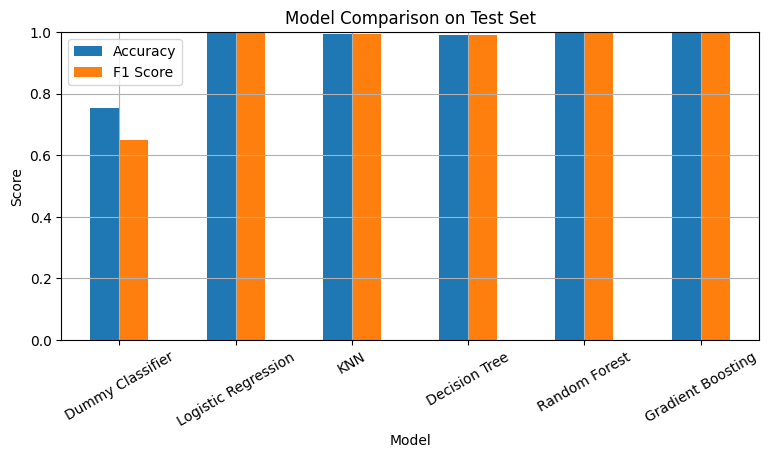

In [97]:
results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(9, 4),
    title="Model Comparison on Test Set",
    ylabel="Score",
    ylim=(0, 1),
    grid=True,
    rot=30
)

plt.show()

The chart shows that all supervised models perform clearly better than the Dummy Classifier baseline. The Dummy Classifier has a relatively high accuracy because it predicts the most frequent cluster, but its F1 Score is much lower. This confirms that accuracy alone is not enough for this imbalanced multi-class problem.

Among the supervised models, Logistic Regression gives the highest test performance in this run, followed very closely by Gradient Boosting and Random Forest. However, the differences between the main supervised models are very small.

The main conclusion is that the K-Means segment labels can be reproduced very well from the selected behavioral features. These results should still be interpreted as cluster reproducibility, not as real external user-type prediction.

## 9. Confusion matrix for Decision Tree


I focus on the Decision Tree because it is easier to interpret than more complex models. The goal here is not only to get a high score, but also to understand where the model makes correct or incorrect cluster predictions.

The confusion matrix compares the actual K-Means cluster labels with the clusters predicted by the Decision Tree. Rows show the actual clusters, and columns show the predicted clusters.

In [98]:
tree_model = models["Decision Tree"]
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

cluster_label_names = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2",
    "Cluster 3"
]

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in cluster_label_names],
    columns=[f"Predicted {label}" for label in cluster_label_names]    
)
cm_df

,Predicted Cluster 0,Predicted Cluster 1,Predicted Cluster 2,Predicted Cluster 3
Actual Cluster 0,1868,0,1,2
Actual Cluster 1,5,481,0,0
Actual Cluster 2,2,0,47,0
Actual Cluster 3,12,1,0,60


The Decision Tree performs very well overall. Most predictions are on the diagonal of the confusion matrix, which means that the predicted cluster is the same as the actual K-Means cluster.

For **Cluster 0**, the model correctly predicts **1868 out of 1871** users. For **Cluster 1**, it correctly predicts **481 out of 486** users. **Cluster 2** is also mostly captured correctly, with **47 out of 49** users predicted correctly.

The largest relative issue appears in **Cluster 3**. The model correctly predicts **60 out of 73** Cluster 3 users, but **12 users from Cluster 3 are predicted as Cluster 0**. This means Cluster 3 is still mostly recognized, but it is the hardest segment for the Decision Tree compared with the other clusters.

Using the interpreted cluster names from the previous notebook, this means that some **Focused Heavy Players** are predicted as **Moderate / Regular Players**. This may happen because some users near the boundary between these two segments have similar values in the behavioral features.

Overall, the confusion matrix shows that the Decision Tree explains the K-Means segments well, but it also reveals where the cluster boundaries are less clear.

## 10. Classification report

The classification report gives precision, recall, and F1-score for each cluster separately. This is useful because the overall weighted scores can hide differences between clusters.

Here, I use the Decision Tree predictions to see which clusters are easier or harder to reproduce.

In [99]:
print(classification_report(y_test, tree_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1871
           1       1.00      0.99      0.99       486
           2       0.98      0.96      0.97        49
           3       0.97      0.82      0.89        73

    accuracy                           0.99      2479
   macro avg       0.98      0.94      0.96      2479
weighted avg       0.99      0.99      0.99      2479



The classification report confirms the confusion matrix results. Cluster 0 and Cluster 1 have very strong precision, recall, and F1-score values. This means the Decision Tree can reproduce these larger segments very accurately.

Cluster 2 also performs well, with an F1-score of about **0.97**, although it has a much smaller support value. Since there are fewer Cluster 2 users in the test set, small changes can affect its score more.

Cluster 3 has the lowest recall, about **0.82**, and the lowest F1-score, about **0.89**. This matches the confusion matrix, where some actual Cluster 3 users were predicted as Cluster 0. In other words, Cluster 3 is the hardest segment for the Decision Tree to separate perfectly.

The weighted average F1-score is still very high, about **0.99**, because the model performs extremely well on most users. However, the macro average recall is lower, about **0.94**, because macro average gives equal importance to each cluster and is more sensitive to the lower recall of Cluster 3.

## 11. Feature importance from Decision Tree

Feature importance helps explain which behavioral variables the Decision Tree uses most when reproducing the K-Means cluster labels.

This is useful because the main purpose of using Decision Tree is interpretation, not only prediction.

In [100]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
7,purchase_ratio,0.762628
5,total_interactions,0.090501
1,avg_hours,0.081997
2,max_hours,0.046394
6,hours_per_game,0.009282
0,total_hours,0.007520
4,purchase_count,0.001513
3,unique_games,0.000165


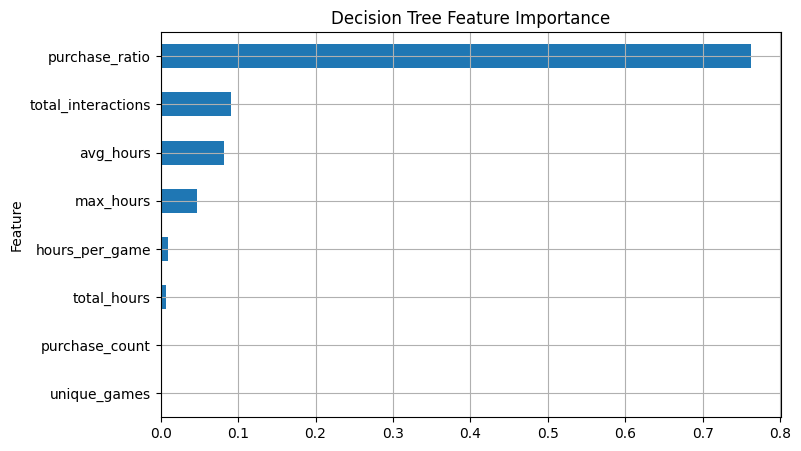

In [101]:
feature_importance.sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(8, 5),
    title="Decision Tree Feature Importance",
    legend=False,
    grid=True
)

plt.show()

The Decision Tree feature importance results show that **purchase_ratio** is by far the most important feature, with an importance value of about **0.763**. This means that the Decision Tree mainly uses the balance between purchasing and playing behavior to separate the K-Means clusters.

The next most important features are **total_interactions**, **avg_hours**, and **max_hours**, but their importance values are much lower than purchase_ratio. This suggests that interaction volume and playtime patterns still help the model, but they are secondary compared with purchase_ratio.

Features such as **hours_per_game**, **total_hours**, **purchase_count**, and **unique_games** have very low importance in this Decision Tree. This does not mean they are useless in the whole project. It only means that, given this specific Decision Tree structure, they are not the main variables used for splitting the testable cluster patterns.

This result is useful for interpretation because it shows that the K-Means segments are strongly connected to purchasing-versus-playing behavior.

## 12. Decision Tree visualization

The Decision Tree visualization helps explain how the model separates the K-Means user segments. Unlike more complex models, a Decision Tree shows the actual decision rules used for classification.

This step is useful because the goal is not only to compare model scores, but also to interpret which behavioral thresholds help separate the discovered user segments.

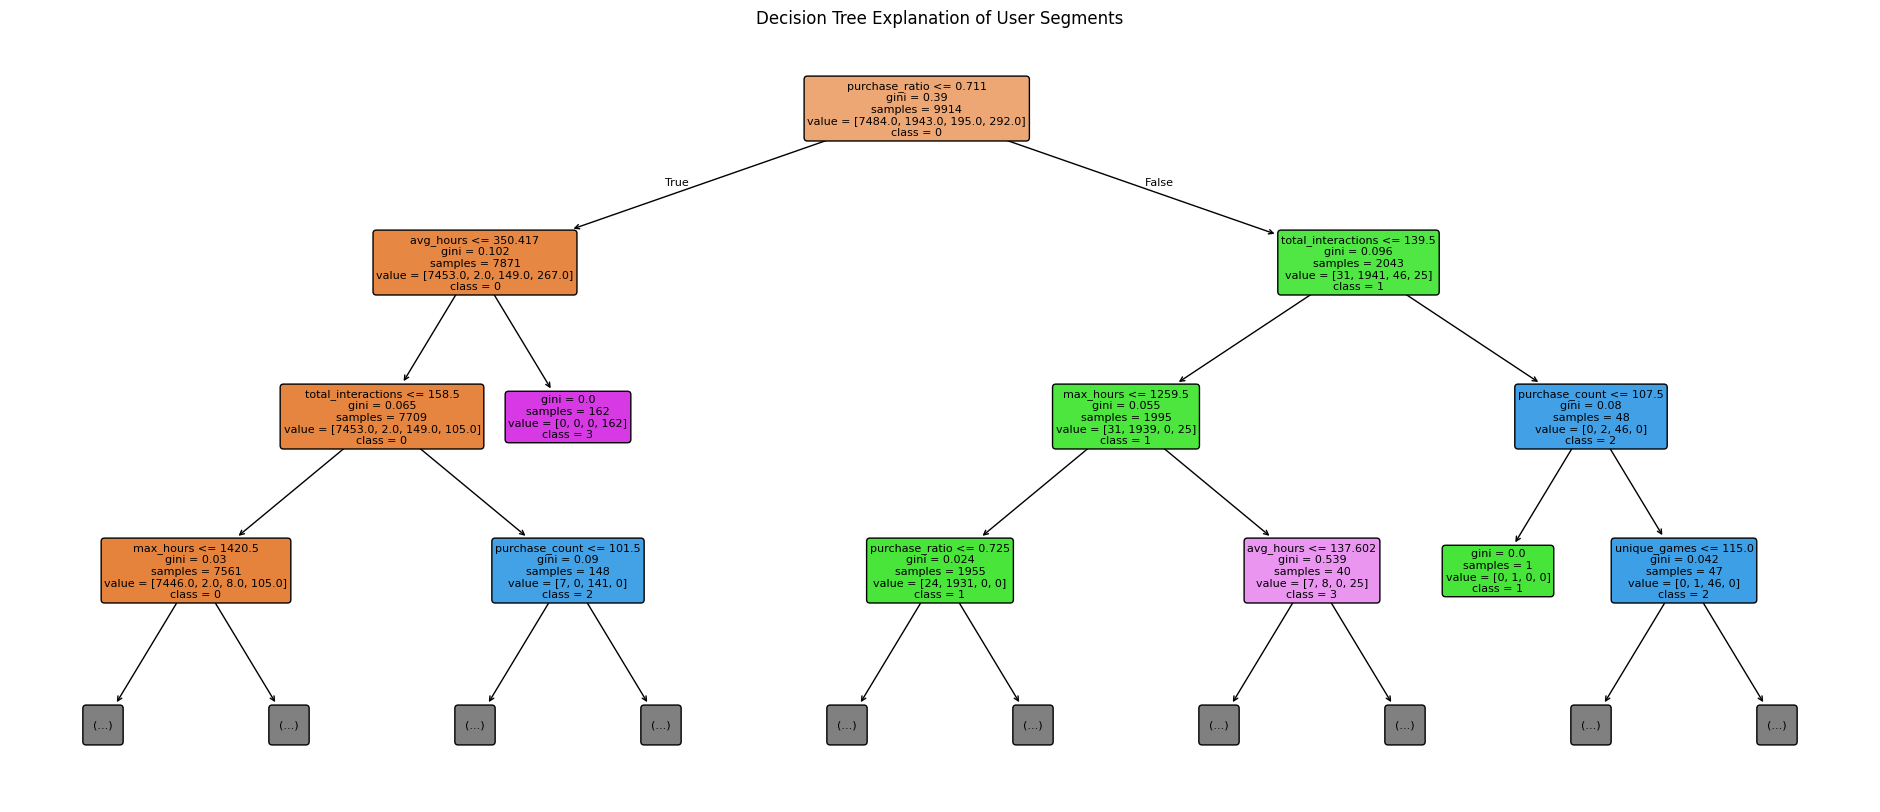

In [102]:
plt.figure(figsize=(24, 10))

plot_tree(
    tree_model,
    feature_names=feature_columns,
    class_names=[str(label) for label in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Explanation of User Segments")
plt.show()

The Decision Tree visualization shows that the first and most important split is based on **purchase_ratio**. This is consistent with the feature importance results, where **purchase_ratio** was by far the most important variable.

This means that the model first separates users based on the balance between purchasing and playing behavior. After that, it uses features such as **avg_hours**, **total_interactions**, **max_hours**, **purchase_count**, and **unique_games** to make more detailed segment decisions.

The tree should not be interpreted as a perfect explanation of real user types, because the target labels are K-Means cluster labels. However, it helps explain how the discovered segments can be reproduced using simple behavioral rules.

Overall, the tree supports the earlier interpretation that purchasing behavior, interaction volume, and playtime intensity are important for separating the Steam user segments.

## 13. Main observations from modeling

The modeling results show that the K-Means segment labels can be reproduced very well using the selected user-level behavioral features.

The Dummy Classifier is useful as a baseline because it only predicts the most frequent cluster. Its performance is clearly lower than the supervised models, which shows that the behavioral features contain useful information for explaining the K-Means segments.

Among the supervised models, Logistic Regression, Gradient Boosting, Random Forest, KNN, and Decision Tree all achieve very high test performance. However, these high scores should be interpreted carefully because the target-like variable is the K-Means `cluster` label, not an external ground-truth user type.

The Decision Tree is especially useful for interpretation. The confusion matrix and classification report show that most clusters are reproduced very well, while Cluster 3 is relatively harder to separate. The feature importance and tree visualization show that **purchase_ratio** is the most important feature for explaining the cluster labels.

Overall, this notebook shows that the discovered user segments are consistent with the selected behavioral features and can be explained using supervised learning models.

## 14. Save model results

I save the model comparison results so that they can be reused later in the Streamlit dashboard and final project summary.

In [103]:
model_results_path = PROCESSED_DATA_DIR / "model_results.csv"

results_df.to_csv(model_results_path, index=False)

model_results_path

PosixPath('/Users/ismailozcan/Desktop/ds570-final-project/data/processed/model_results.csv')

The saved `model_results.csv` file contains the test set performance of each model. This makes it easier to reuse the model comparison table in the dashboard without rerunning the notebook.

## 15. Final note

This modeling notebook does not claim to predict real external user types. Instead, it uses supervised models to explain and reproduce the K-Means user segments created in the previous notebook.

The results show that the selected behavioral features are strongly connected to the discovered segments. The Decision Tree analysis also gives an interpretable view of which features are most useful for separating the user groups.